### Imports

In [23]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Load video

Dimensions: (1020, 110)   FPS: 60.0   Duration: 29.65


C:\Users\2013r\AppData\Local\Temp\ipykernel_33100\3334219821.py:17: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  corners = np.int0(corners)


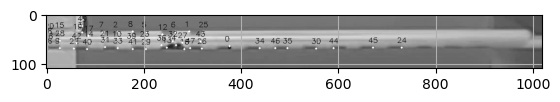

In [24]:
video = cv2.VideoCapture('video/output_20240301_031652.avi')
fps = video.get(cv2.CAP_PROP_FPS)
frame_count = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps
dimensions = (int(video.get(3)), int(video.get(4)))
print(f'Dimensions: {dimensions}   FPS: {fps}   Duration: {duration}')

# Read the first frame
success, frame = video.read()
if not success:
    print('Failed to read video')
    exit(1)
gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')

corners = cv2.goodFeaturesToTrack(gray, 50, 0.01, 10)
corners = np.int0(corners)
for c, corner in enumerate(corners):
    x, y = corner.ravel()
    cv2.circle(gray, (x, y), 2, 255, -1)
    cv2.putText(gray, str(c), (x-10, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    
plt.imshow(gray, cmap='gray')
plt.grid()

In [25]:
scale_point1 = corners[46]
scale_point2 = corners[35]

ACTUAL_LENGTH = 0.85  # mm
image_length = np.linalg.norm(scale_point1 - scale_point2)
mm_per_pixel = ACTUAL_LENGTH / image_length
print(f'mm/pixel: {mm_per_pixel}')

video.release()
cv2.destroyAllWindows()

mm/pixel: 0.034


#### Load camera data

In [26]:
df_cam = pd.read_csv('csv/output_20240301_031652.csv')
df_cam.head()

,time,x,y
0,0.012897,377.0,68.0
1,0.035831,377.0,68.0
2,0.055584,377.0,68.0
3,0.084319,378.0,68.0
4,0.103297,378.0,68.0


x1: 12.87 ± 0.02 mm   y1: 2.32 ± 0.02 mm
x2: 15.67 ± 0.01 mm   y2: 2.35 ± 0.00 mm
Δx: 2.80 mm   Δy: 0.02 mm


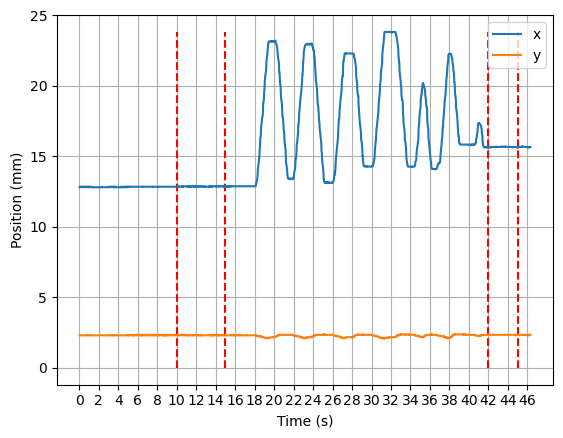

In [27]:
time_cam = df_cam['time'].values
x_cam = df_cam['x'].values
y_cam = df_cam['y'].values

x_cam_mm = x_cam * mm_per_pixel
y_cam_mm = y_cam * mm_per_pixel

trange1 = [10, 15]
trange2 = [42, 45]
time_range1 = np.argwhere((time_cam >= trange1[0]) & (time_cam <= trange1[1])).ravel()
time_range2 = np.argwhere((time_cam >= trange2[0]) & (time_cam <= trange2[1])).ravel()

x_cam_mean1 = np.mean(x_cam_mm[time_range1])
x_cam_std1 = np.std(x_cam_mm[time_range1])
y_cam_mean1 = np.mean(y_cam_mm[time_range1])
y_cam_std1 = np.std(y_cam_mm[time_range1])

x_cam_mean2 = np.mean(x_cam_mm[time_range2])
x_cam_std2 = np.std(x_cam_mm[time_range2])
y_cam_mean2 = np.mean(y_cam_mm[time_range2])
y_cam_std2 = np.std(y_cam_mm[time_range2])

print(f'x1: {x_cam_mean1:.2f} ± {x_cam_std1:.2f} mm   y1: {y_cam_mean1:.2f} ± {y_cam_std1:.2f} mm')
print(f'x2: {x_cam_mean2:.2f} ± {x_cam_std2:.2f} mm   y2: {y_cam_mean2:.2f} ± {y_cam_std2:.2f} mm')

x_cam_diff = x_cam_mean2 - x_cam_mean1
y_cam_diff = y_cam_mean2 - y_cam_mean1
print(f'Δx: {x_cam_diff:.2f} mm   Δy: {y_cam_diff:.2f} mm')

plt.vlines(trange1, 0, np.max(x_cam_mm), colors='r', linestyles='dashed')
plt.vlines(trange2, 0, np.max(x_cam_mm), colors='r', linestyles='dashed')
plt.plot(time_cam, x_cam_mm, label='x')
plt.plot(time_cam, y_cam_mm, label='y')
plt.xlabel('Time (s)')
plt.ylabel('Position (mm)')
plt.legend()
plt.xticks(np.arange(0, time_cam[-1], 2))
plt.grid()

#### Load motor data

In [28]:
df_motor = pd.read_csv('stream_data_2024-03-01_03-17-08.csv')
df_motor.head()

,Time,Motor1 Apos,Opten1 PosX,Opten1 PosY,Motor2 Apos,Opten2 PosX,Opten2 PosY
0,0.297,0.0,0.0,0.0,0.0,-0.002,0.0
1,0.386,0.0,0.0,0.0,0.0,-0.002,0.0
2,0.437,0.0,0.0,0.0,0.0,-0.002,0.0
3,0.500,0.0,0.0,0.0,0.0,-0.002,0.0
4,0.565,0.0,0.0,0.0,0.0,-0.002,0.0


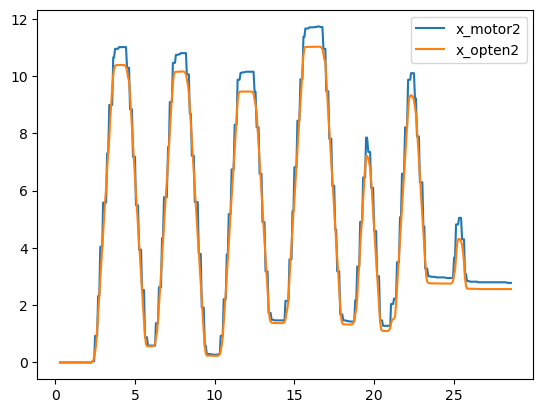

In [29]:
time_motor = df_motor['Time'].values
x_motor1 = -df_motor['Motor1 Apos'].values
x_opten1 = -df_motor['Opten1 PosX'].values
y_opten1 = -df_motor['Opten1 PosY'].values
x_motor2 = -df_motor['Motor2 Apos'].values
x_opten2 = -df_motor['Opten2 PosX'].values
y_opten2 = -df_motor['Opten2 PosY'].values

plt.plot(time_motor, x_motor2, label='x_motor2')
plt.plot(time_motor, x_opten2, label='x_opten2')
plt.legend()

### Alignment

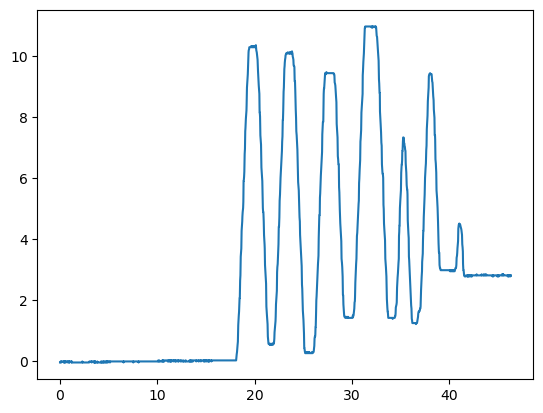

In [33]:
x_cam_zeroed = x_cam_mm - x_cam_mean1

time_shift = -15
time_cam_shifted = time_cam + time_shift

plt.plot(time_cam, x_cam_zeroed, label='x_cam')

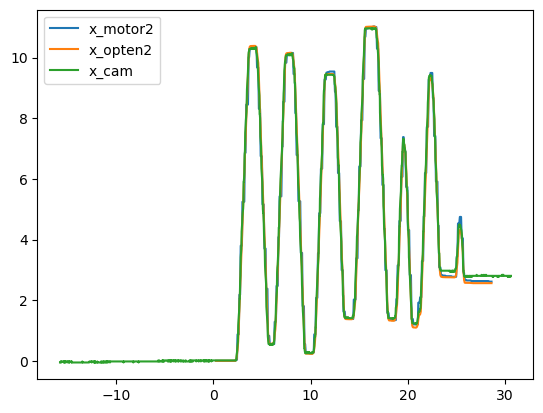

In [46]:
plt.plot(time_motor, x_motor2*0.94, label='x_motor2')
plt.plot(time_motor, x_opten2, label='x_opten2')
plt.plot(time_cam-15.75, x_cam_zeroed, label='x_cam')
plt.legend()

In [47]:
52.5/0.94

55.851063829787236

In [57]:
1/((27.5/2+1.14)*0.00153)

43.89488054008261